<h1>Train — ResNet-18 (baseline)</h1>

Trains and evaluates the ResNet-18 baseline classifier, then saves its results (`results_resnet18.pkl`) and weights (`{COMPONENT}_resnet18_cnn.pt`) to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1196 | Val: 336 | Test: 189


## Define the model (Transfer Learning with ResNet-18)

In [2]:
model_resnet18 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

num_ftrs = model_resnet18.fc.in_features
model_resnet18.fc = nn.Linear(num_ftrs, num_classes)  # no hidden layers — this one predates the tuning sweep

model_resnet18 = model_resnet18.to(device)

# ---------------------------------------------------------
# Loss and optimizer, with class weights for the imbalanced classes
# ---------------------------------------------------------
class_weights = make_class_weights(train_ds)
print("Applying class weights to loss function:")
for name, w in zip(class_names, class_weights.cpu().numpy()):
    print(f"  {name:<15s}: {w:.3f}")

criterion_resnet18 = nn.CrossEntropyLoss(weight=class_weights)
optimizer_resnet18 = optim.Adam(model_resnet18.parameters(), lr=5e-4, weight_decay=WEIGHT_DECAY)

# mode='min' because we want to minimize loss; factor=0.5 halves the LR when
# triggered; patience=3 waits 3 epochs with no improvement before reducing it
scheduler_resnet18 = ReduceLROnPlateau(optimizer_resnet18, mode='min', factor=0.5, patience=3)

Applying class weights to loss function:
  Dysfunctional  : 0.515
  Functional     : 0.599
  Suboptimal     : 1.887


## Train, then plot training curves

[ResNet-18] Epoch   1/100 | LR: 5.00e-04 | train loss 1.1134 acc 0.545 | val loss 1.2488 acc 0.506 *
[ResNet-18] Epoch   2/100 | LR: 5.00e-04 | train loss 0.7863 acc 0.664 | val loss 0.6963 acc 0.723 *
[ResNet-18] Epoch   3/100 | LR: 5.00e-04 | train loss 0.6768 acc 0.718 | val loss 0.6695 acc 0.699 *
[ResNet-18] Epoch   4/100 | LR: 5.00e-04 | train loss 0.6991 acc 0.743 | val loss 0.8009 acc 0.682
[ResNet-18] Epoch   5/100 | LR: 5.00e-04 | train loss 0.6396 acc 0.748 | val loss 0.6033 acc 0.735 *
[ResNet-18] Epoch   6/100 | LR: 5.00e-04 | train loss 0.6197 acc 0.754 | val loss 0.7671 acc 0.679
[ResNet-18] Epoch   7/100 | LR: 5.00e-04 | train loss 0.5881 acc 0.778 | val loss 0.5433 acc 0.762 *
[ResNet-18] Epoch   8/100 | LR: 5.00e-04 | train loss 0.5475 acc 0.773 | val loss 0.6001 acc 0.744
[ResNet-18] Epoch   9/100 | LR: 5.00e-04 | train loss 0.5756 acc 0.765 | val loss 0.5015 acc 0.804 *
[ResNet-18] Epoch  10/100 | LR: 5.00e-04 | train loss 0.5350 acc 0.813 | val loss 0.4859 acc 0.80

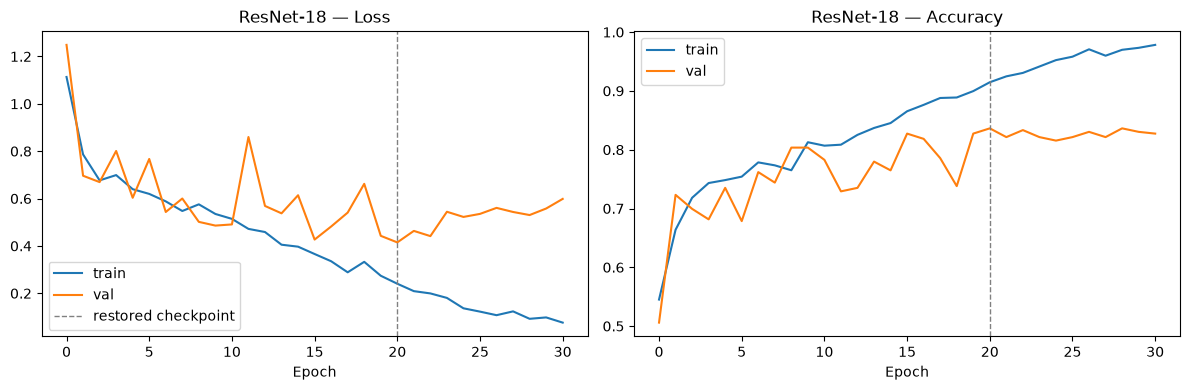

In [3]:
history_resnet18 = train_model(
    model_resnet18, train_loader, val_loader, optimizer_resnet18, scheduler_resnet18,
    criterion_resnet18, EPOCHS, EARLY_STOP_PATIENCE, "ResNet-18",
)
plot_training_curves(history_resnet18, "ResNet-18")

## Evaluate on the test set

[ResNet-18] Test accuracy: 0.751


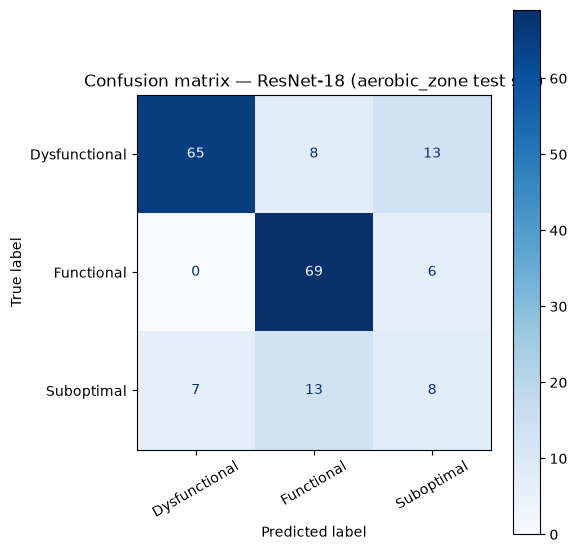

               precision    recall  f1-score   support

Dysfunctional      0.903     0.756     0.823        86
   Functional      0.767     0.920     0.836        75
   Suboptimal      0.296     0.286     0.291        28

     accuracy                          0.751       189
    macro avg      0.655     0.654     0.650       189
 weighted avg      0.759     0.751     0.749       189



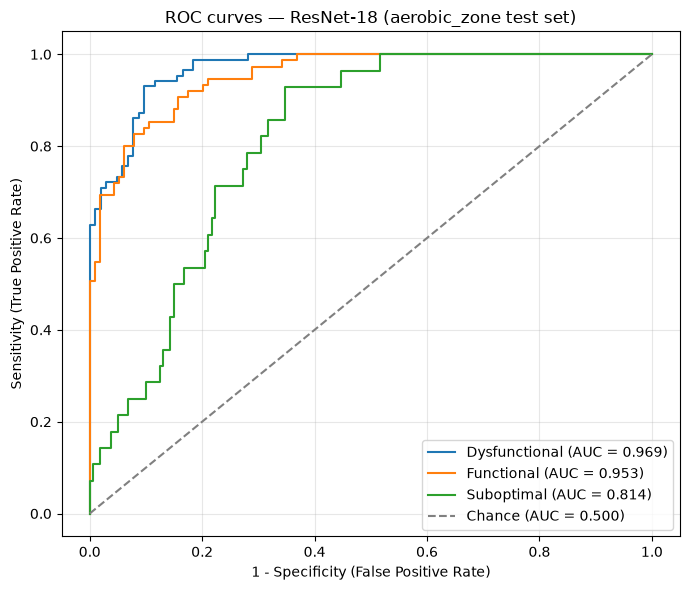

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.969
  Functional     : 0.953
  Suboptimal     : 0.814

Mean AUC: 0.912


(np.float64(0.7513227513227513),
 {'Dysfunctional': 0.9692932941973358,
  'Functional': 0.9530994152046783,
  'Suboptimal': 0.8143300798580302})

In [4]:
evaluate_and_record(
    model_resnet18, test_loader, "ResNet-18", history_resnet18,
    img_size=IMG_TARGET_SIZE, hidden_layers=0, neurons=None,
)

## Save results + model weights to disk

This is the step the results notebook depends on — it pickles the metrics/history and saves the model state dict so nothing needs to be kept in memory or re-trained.

In [5]:
save_result("ResNet-18", "resnet18")

Saved results to ../results/results_aerobic_zone_resnet18.pkl
Saved model weights to ../models/aerobic_zone_resnet18_cnn.pt
